# Read training data of forcesmip6 challenge

In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

# Get Test data in Evaluation Tier1 

In [3]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  

In [4]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

  Processing 7: 1A.tas.EM.1950-2022.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 15: 1B.tas.EM.1950-2022.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 31: 1D.tas.EM.1950-2022.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 55: 1G.tas.EM.1950-2022.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 71: 1J.tas.EM.1950-2022.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)


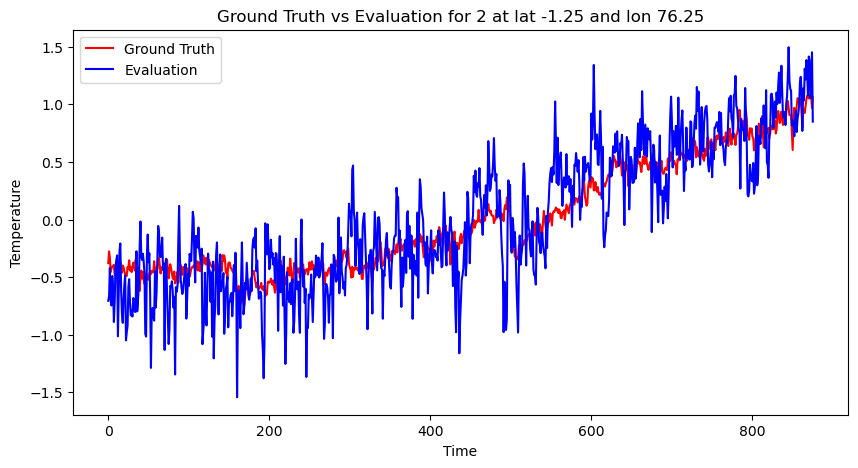

In [5]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 2
idx_lat = 35
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# Merge training data to train the ridge regression model

In [6]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [7]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [8]:
# vars = {}
# means = {}

# # for each model, compute the variance of the anomaly
# for dir in DIR_LIST:
#     print(f'Computing variance for {dir}')
#     vars[dir] = np.nanvar(dic_data[dir], axis=0)
#     means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)

In [ ]:
# compute training set and test set
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)

  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


# Get the estimates of the other methods

In [10]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)


for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[5] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[5])
            print(f'  Found test data for {file[5]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')

lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 51/80: tas_1A_1950_2022.nc
  Found test data for A at index 0
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Found test data for B at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Found test data for C at index 2
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Found test data for D at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Found test data for E at index 4
  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Found test data for F at index 5
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Found test data for G at index 6
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Found test data for H at index 7
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Found test data for I at index 8
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.

In [11]:
data_estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1], data_estimates.shape[2]//12, 72, 144), dtype=np.float32)
for idx_m in range(data_estimates.shape[0]):
    data_estimates_yearly[idx_m,:,:,:,:] = yearly_average(data_estimates[idx_m,:,:,:], months_per_year=12)

In [12]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

mse_estimates[:,8] = 0.0

  MSE estimates: [0.49550778 0.51100057 0.67596477 0.84101903 0.48415652 0.47930476
 0.61143172 0.43098748 0.64807928 0.51178229]
  MSE estimates: [0.51639372 0.5460459  0.65299219 0.7674492  0.49941075 0.50957346
 0.57887173 0.46936822 0.68619871 0.59348494]
  MSE estimates: [0.49182796 0.5012449  0.58460832 0.87728935 0.48170397 0.48428568
 0.55289179 0.44784209 0.7546466  0.57025641]
  MSE estimates: [0.43085137 0.56283027 0.78117096 0.44237232 0.5036909  0.4146412
 0.49771696 0.31438255 0.44269887 0.48009971]
  MSE estimates: [0.42836311 0.43215752 0.62536472 0.59834325 0.44574437 0.43019038
 0.52151704 0.38851166 0.53218716 0.47624314]
  MSE estimates: [0.36044395 0.38175088 0.56761026 0.45852318 0.4024646  0.35533607
 0.47676918 0.31087133 0.44567934 0.43520856]
  MSE estimates: [0.38899282 0.41481045 0.6190955  0.73331398 0.422548   0.38153708
 0.50368208 0.33451095 0.55205292 0.43823734]
  MSE estimates: [0.49169007 0.50437868 0.69514912 0.77526796 0.50779128 0.50623846
 0.5940

# Yearly data

In [13]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data , months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

# Reshape the data to have the shape (runs, years, latitude * longitude)
x_test = data_test.reshape(data_test.shape[0], data_test.shape[1], longitude.shape[0]*latitude.shape[0])
y_test = data_ground_truth_test.reshape(data_ground_truth_test.shape[0], data_ground_truth_test.shape[1], longitude.shape[0]*latitude.shape[0])

x_test_yearly = yearly_average(data_test, months_per_year=12)
x_test_yearly = x_test_yearly.reshape(x_test_yearly.shape[0], x_test_yearly.shape[1], longitude.shape[0]*latitude.shape[0])

y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)
y_test_yearly = y_test_yearly.reshape(y_test_yearly.shape[0], y_test_yearly.shape[1], longitude.shape[0]*latitude.shape[0])


In [14]:
# compute the yearly mse of the other estimates 
# compute mse of the other estimates
mse_estimates_yearly = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates_yearly[idx_r,:] = np.sqrt(np.mean((data_estimates_yearly[idx_r,:,:,:,:] - y_test_yearly.reshape(y_test_yearly.shape[0],y_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates_yearly[idx_r,:]}')

mse_estimates_yearly[:,8] = 0.0

  MSE estimates: [0.37383133 0.3708767  0.4062196  0.76184803 0.32120651 0.35452175
 0.42573875 0.33269256 0.64733458 0.36297438]
  MSE estimates: [0.27060661 0.31422687 0.38259467 0.57667619 0.24059433 0.2883026
 0.3127341  0.24202834 0.50444114 0.30820149]
  MSE estimates: [0.2422356  0.27296612 0.30938172 0.70761365 0.23452061 0.26511165
 0.29515049 0.22072785 0.58849251 0.27288583]
  MSE estimates: [0.24872847 0.41958332 0.59430546 0.26345435 0.33542052 0.26470819
 0.28473562 0.17410477 0.40600315 0.28350335]
  MSE estimates: [0.23232105 0.22750515 0.3108114  0.46762332 0.23152888 0.24322759
 0.25804055 0.24359913 0.50619024 0.26351762]
  MSE estimates: [0.17775716 0.19806424 0.31116292 0.31416944 0.21652955 0.19101632
 0.24898265 0.17137657 0.42787263 0.2441894 ]
  MSE estimates: [0.20660196 0.21705036 0.25775272 0.63489521 0.20965408 0.19503611
 0.24261999 0.18128304 0.5439589  0.24459068]
  MSE estimates: [0.28973687 0.27461651 0.3698864  0.60792452 0.25935444 0.31967053
 0.3275

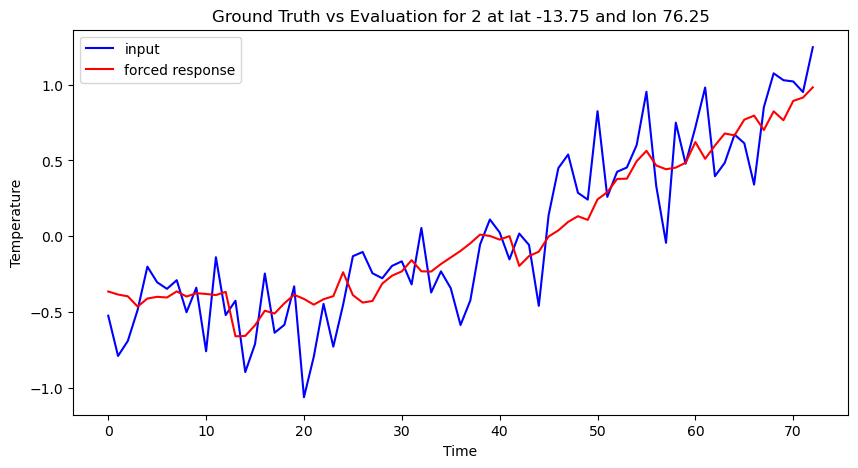

In [15]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(x_test_yearly.reshape(10,y_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='input', color='blue')
plt.plot(y_test_yearly.reshape(10,y_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='forced response', color='red')
# plt.plot(y_test_yearly.reshape(10,y_test_yearly.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='forced response', color='red')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

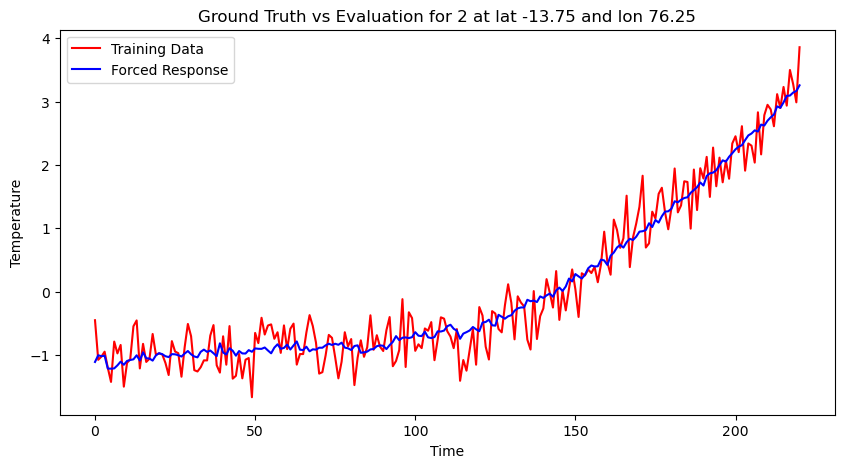

In [16]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [17]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)

Computing variance for CESM2
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


In [18]:
# train the models on yearly data
# compute training set and test set
# dic_data_yearly_tmp = normalize_data(dic_data_yearly,means_yearly,vars_yearly)
# dic_forced_response_yearly_tmp = normalize_data(dic_forced_response_yearly,means_yearly,vars_yearly)
x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])


  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])


In [ ]:
# save x_yearly and y_yearly in a dictionary within pickle file 

# import pickle
# with open('data_yearly.pickle', 'wb') as f:
#     pickle.dump({'dic_data_yearly': x_yearly, 'dic_forced_response_yearly': y_yearly}, f)


# Construct the dataset with a time index feature

In [20]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train   # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
years_test_idx_feature =  years_test

In [21]:
from preprocessing import stack_models_and_runs

# stack the models and runs for the training data
x_train_yearly_stacked, y_train_yearly_stacked = stack_models_and_runs(list(dic_data.keys()), x_yearly, y_yearly)


# get the numpy version of the data
x_train_yearly_stacked = x_train_yearly_stacked.numpy()
y_train_yearly_stacked = y_train_yearly_stacked.numpy()

In [22]:
from algorithms import ridge_regression
# proximal_algorithm_ridge_trace_penalty,train_trace_norm_ridge

# penalty parameters
lambda_tmp = 2500.0

# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

Loss function:  465614.0625


In [23]:
# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly@w_ridge,full_matrices=False)

rank = 5
w_ridge_low_rank = w_ridge @ V[:rank,:].T@V[:rank,:]

In [24]:
import torch.nn.functional as F

def moving_average_smoothing(x, window_size=5, mode='same'):
    """
    Apply moving average smoothing to multivariate time series using PyTorch.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
           where first dimension is number of samples, second is time, third is features
        window_size: int, size of the moving average window
        mode: str, padding mode - 'same' keeps original length, 'valid' reduces length
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input (if mode='same') or reduced size
    """
    n_samples, n_timesteps, n_features = x.shape
    
    # Create uniform kernel for moving average
    kernel = torch.ones(1, 1, window_size, dtype=x.dtype, device=x.device) / window_size
    
    # Reshape input for conv1d: (batch_size * n_features, 1, n_timesteps)
    x_reshaped = x.permute(0, 2, 1).reshape(n_samples * n_features, 1, n_timesteps)
    
    # Apply padding if mode is 'same'
    if mode == 'same':
        padding = window_size // 2
        x_padded = F.pad(x_reshaped, (padding, padding), mode='reflect')
        smoothed = F.conv1d(x_padded, kernel)
        
        # Ensure output has the same length as input by trimming if necessary
        if smoothed.shape[-1] > n_timesteps:
            # Trim the extra timestep(s) from the end
            smoothed = smoothed[:, :, :n_timesteps]
        elif smoothed.shape[-1] < n_timesteps:
            # This shouldn't happen with proper padding, but handle it just in case
            padding_needed = n_timesteps - smoothed.shape[-1]
            smoothed = F.pad(smoothed, (0, padding_needed), mode='replicate')
            
    else:  # mode == 'valid'
        smoothed = F.conv1d(x_reshaped, kernel)
    
    # Reshape back to original format
    if mode == 'same':
        smoothed = smoothed.reshape(n_samples, n_features, n_timesteps).permute(0, 2, 1)
    else:
        new_timesteps = smoothed.shape[-1]
        smoothed = smoothed.reshape(n_samples, n_features, new_timesteps).permute(0, 2, 1)
    
    return smoothed

In [25]:
x_test_torch = torch.from_numpy(x_test).to(torch.float32)
y_test_torch = torch.from_numpy(y_test).to(torch.float32)

x_test_ma = moving_average_smoothing(x_test_torch, window_size=40, mode='same')

# preditcion on test data
y_pred = x_test_torch @ w_ridge
y_pred_lr = x_test_torch @ w_ridge_low_rank


# compute the mse
rmse = torch.sqrt(torch.mean((y_pred - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_lr - y_test) ** 2,axis=(1,2))).detach().numpy()

print(f'MSE Ridge Regression: {rmse}')
print(f'MSE Low Rank Ridge Regression: {rmse_low_rank}')

MSE Ridge Regression: [0.40454793 0.43047857 0.5538211  0.58273536 0.42920256 0.38080812
 0.50221115 0.3529416  0.59065133 0.48514697]
MSE Low Rank Ridge Regression: [0.4026136  0.42663342 0.5662514  0.58577204 0.43482193 0.3856167
 0.499955   0.3514953  0.57919747 0.48072466]


In [26]:
rmse[8] = 0.0
rmse_low_rank[8] = 0.0

In [27]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['median'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['75th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['90th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['95th'] = np.zeros(mse_estimates.shape[0]+4)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates.shape[0]+4)

# compute also the variance of mse estimates
stats_mse_estimates['variance'] = np.zeros(mse_estimates.shape[0]+4)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank, axis=0)



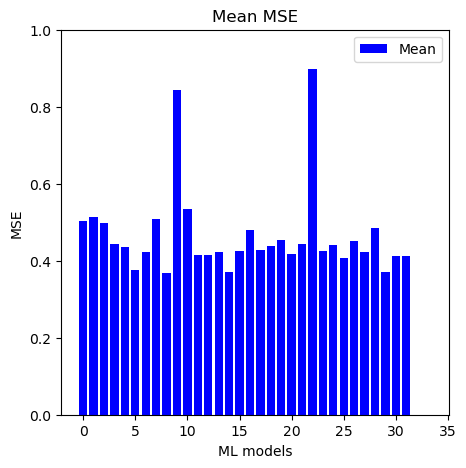

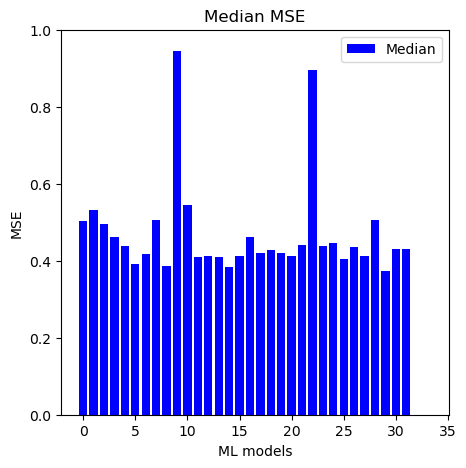

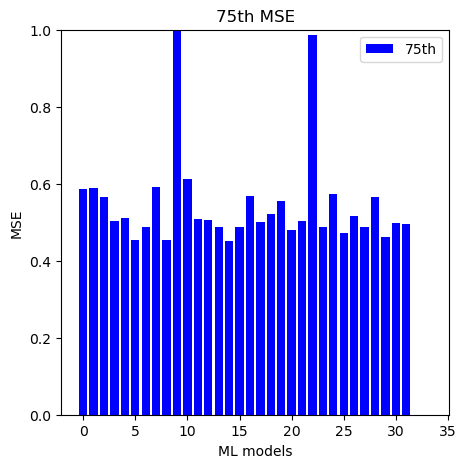

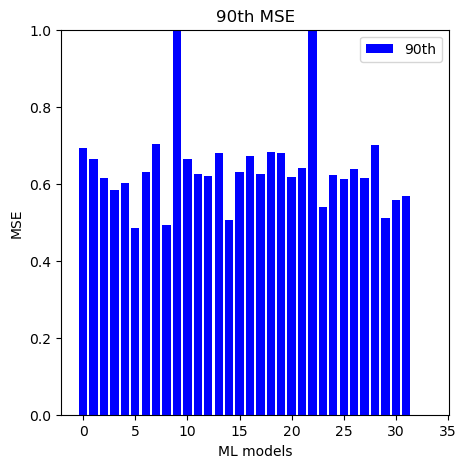

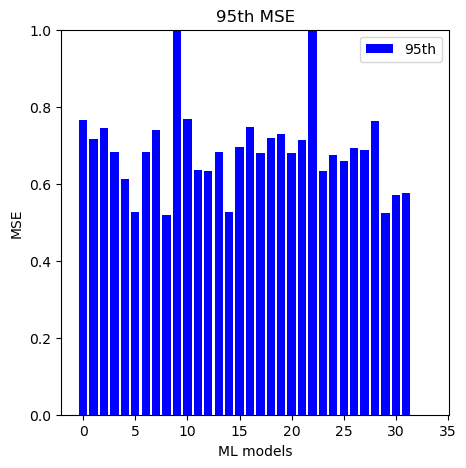

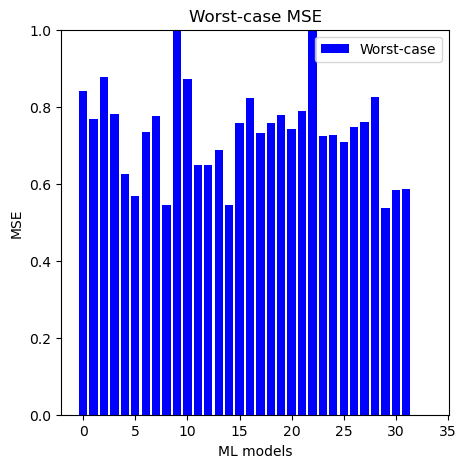

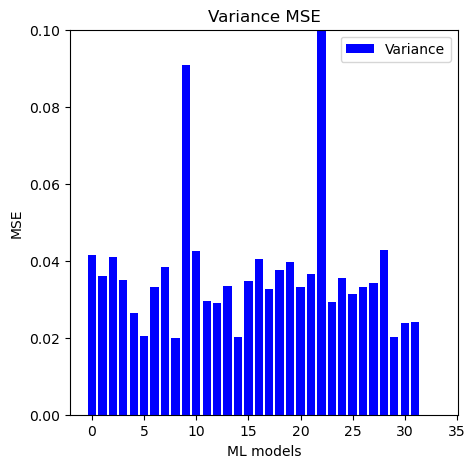

In [28]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

# Idea: Test by combining the predictions of different denoising models

In [29]:
# Test the M denoising models and weighted predictions

w_ridge_per_model = {}
w_ridge_low_rank_per_model = {}

rmse_per_model = {}
rmse_low_rank_per_model = {}

lambda_tmp = 2500.0


for dir in list(dic_data_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = torch.from_numpy(dic_data_yearly[dir]).to(torch.float32).reshape(dic_data_yearly[dir].shape[0]*dic_data_yearly[dir].shape[1],dic_data_yearly[dir].shape[2]*dic_data_yearly[dir].shape[3])    
    y_train_yearly_tmp = torch.from_numpy(dic_forced_response_yearly[dir]).to(torch.float32).reshape(dic_forced_response_yearly[dir].shape[0]*dic_forced_response_yearly[dir].shape[1],dic_forced_response_yearly[dir].shape[2]*dic_forced_response_yearly[dir].shape[3])

    w_ridge_per_model[dir] = ridge_regression(x_train_yearly_tmp, y_train_yearly_tmp, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

    # low rank regression
    U,S,V = torch.linalg.svd(x_train_yearly_tmp@w_ridge_per_model[dir],full_matrices=False)

    # # define the rank
    rank = 30

    w_ridge_low_rank_per_model[dir] = w_ridge_per_model[dir] @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = x_test_torch @ w_ridge_per_model[dir]
    y_pred_low_rank_tmp= x_test_torch @ w_ridge_low_rank_per_model[dir]

    # Compute the mean squared error
    rmse_per_model[dir] = torch.sqrt(torch.mean((y_pred_tmp - y_test_torch) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank_per_model[dir] = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_torch) ** 2,axis=(1,2))).detach().numpy()


    print(f'  MSE : {rmse_per_model[dir]}')
    print(f'  MSE trace norm: {rmse_low_rank_per_model[dir]}')

Computing ridge regression for CESM2
Loss function:  1929733.0
  MSE : [0.40284732 0.42760336 0.7175828  0.4508784  0.4558051  0.35231188
 0.5378715  0.37737063 0.44139633 0.44684646]
  MSE trace norm: [0.40351596 0.42795625 0.71893895 0.45208374 0.45654947 0.3528012
 0.5386029  0.37752098 0.44056976 0.4477754 ]
Computing ridge regression for CanESM5
Loss function:  2691214.75
  MSE : [0.44425523 0.45160034 0.54621977 0.65313804 0.46843258 0.41428277
 0.5236468  0.3914812  0.54677176 0.49742332]
  MSE trace norm: [0.44409356 0.4512324  0.5482278  0.6540829  0.46900642 0.41400352
 0.5240545  0.39051464 0.54456455 0.49824196]
Computing ridge regression for MIROC-ES2L
Loss function:  1267539.125
  MSE : [0.4058265  0.42873436 0.65064645 0.5529598  0.439127   0.4128232
 0.50421906 0.3267333  0.49186626 0.48021945]
  MSE trace norm: [0.40645182 0.429046   0.6526413  0.55454534 0.44011837 0.4132361
 0.5049584  0.32672238 0.49038553 0.4813998 ]
Computing ridge regression for MIROC6
Loss funct

In [30]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def distance_to_training_data(x, x_train):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    distances = torch.zeros((x.shape[0]), dtype=torch.float32)
    for i in range(x.shape[0]):
        distances[i] = torch.mean(torch.sqrt(torch.sum((x[i,:,:] - x_train[:,years_test_idx_feature,:]) ** 2, dim=(1, 2))),axis=0)
    print(f'  distances shape: {distances.shape}')
    return distances

def compute_weights(x,x_train):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((x.shape[0],len(x_train.keys())) , dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(x_train.keys())):
        distances[m] = distance_to_training_data(x,x_train[m])
        print(f'  distances for model {m} shape: {distances[m].shape}')
        weights[:,idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

In [31]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def training_losses(x, y, w):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        w: torch.Tensor of shape (n_features, n_outputs)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    y_pred = x @ w
    distances = torch.sqrt(torch.mean((y_pred - y) ** 2, dim=(1, 2)))
    return distances

def compute_weights_training_losses(w,x,y):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((len(w.keys())), dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(w.keys())):
        distances[m] = torch.mean(training_losses(x[m],y[m],w[m]))
        weights[idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

In [32]:
# compute weighted prediction
def weighted_prediction(weights, w, x):
    """
    Compute the weighted prediction based on the weights and the model coefficients.
    
    Args:
        weights: torch.Tensor of shape (n_models, n_samples)
        w: dict of model coefficients
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    Returns:
        y_pred: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    """
    y_pred = torch.zeros((x.shape[0], x.shape[1], x.shape[2]), dtype=torch.float32)
    
    for idx_m, m in enumerate(list(w.keys())):
        y_pred += weights[idx_m] * (x @ w[m])
    
    return y_pred

In [33]:
weights = compute_weights_training_losses(w_ridge_per_model, x_yearly, y_yearly)
weights_lr = compute_weights_training_losses(w_ridge_low_rank_per_model, x_yearly, y_yearly)

y_pred = weighted_prediction(weights, w_ridge_per_model, x_test_torch)
y_pred_low_rank = weighted_prediction(weights_lr, w_ridge_low_rank_per_model, x_test_torch)

# Compute the mean squared error
rmse_weighted = torch.sqrt(torch.mean((y_pred - y_test) ** 2, axis=(1, 2))).detach().numpy()
rmse_weighted_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test) ** 2, axis=(1, 2))).detach().numpy()

rmse_weighted[8] = 0.0
rmse_weighted_low_rank[8] = 0.0

print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')
print(f'  MSE weighted prediction: {rmse_weighted}')
print(f'  MSE weighted prediction trace norm: {rmse_weighted_low_rank}')

  MSE: [0.40454793 0.43047857 0.5538211  0.58273536 0.42920256 0.38080812
 0.50221115 0.3529416  0.         0.48514697]
  MSE trace norm: [0.4026136  0.42663342 0.5662514  0.58577204 0.43482193 0.3856167
 0.499955   0.3514953  0.         0.48072466]
  MSE weighted prediction: [0.36483854 0.38302842 0.6073561  0.45622617 0.40845063 0.35978594
 0.47918358 0.30768594 0.         0.43458608]
  MSE weighted prediction trace norm: [0.36598095 0.383558   0.60943043 0.45797887 0.40978548 0.36028272
 0.48022154 0.3080507  0.         0.43592328]


In [34]:
stats_mse_estimates['mean'][data_estimates.shape[0]+2] = np.mean(rmse_weighted, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+2] = np.median(rmse_weighted, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+2] = np.quantile(rmse_weighted, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+2] = np.quantile(rmse_weighted, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+2] = np.quantile(rmse_weighted, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+2] = np.max(rmse_weighted, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+2] = np.var(rmse_weighted, axis=0)

stats_mse_estimates['mean'][data_estimates.shape[0]+3] = np.mean(rmse_weighted_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+3] = np.median(rmse_weighted_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+3] = np.max(rmse_weighted_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+3] = np.var(rmse_weighted_low_rank, axis=0)

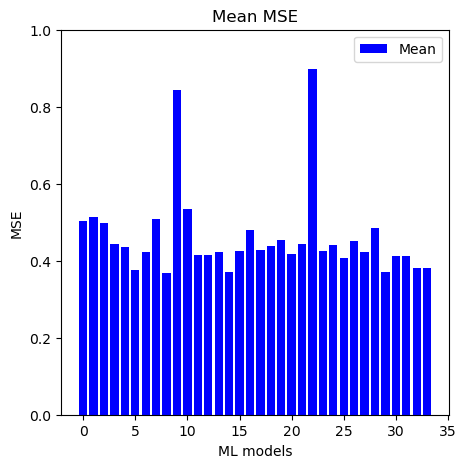

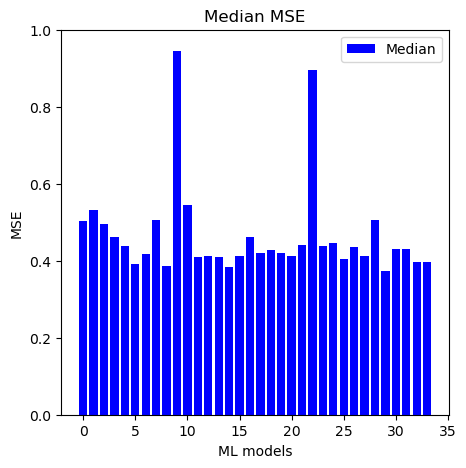

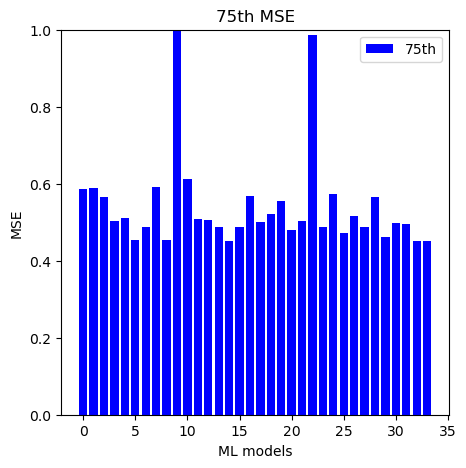

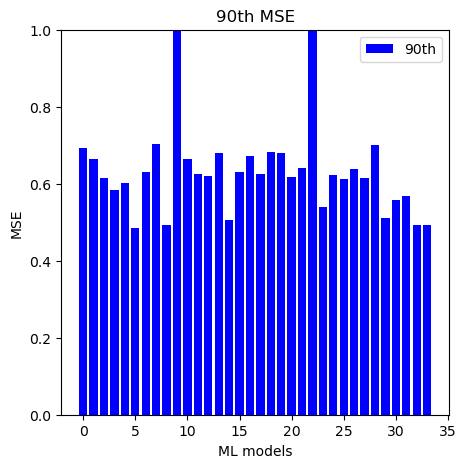

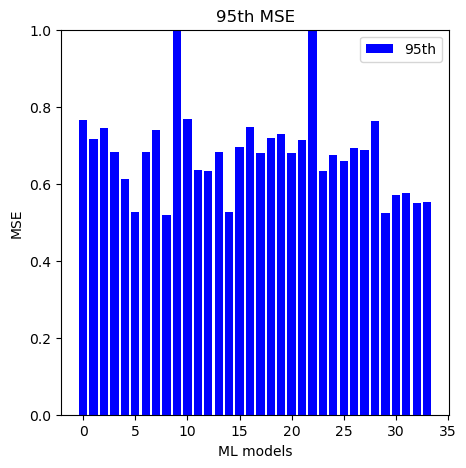

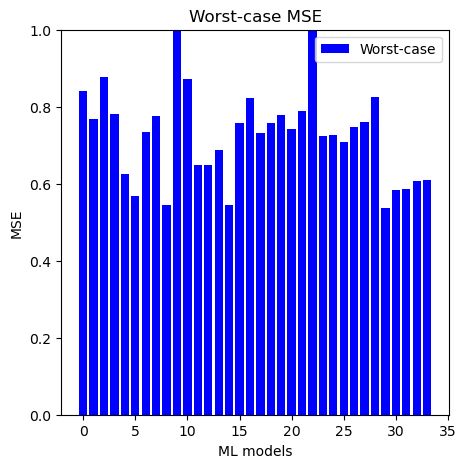

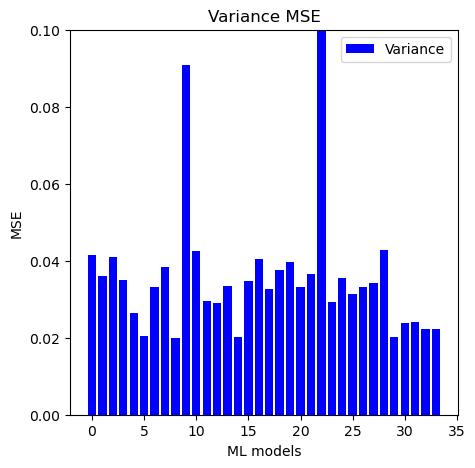

In [35]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

In [38]:
import tensorly

def train_lowrank_tensor_regression(x, y, lambda_, nb_iterations=10, dtype=torch.float32, verbose=False):
    """ Train the trace penalty ridge regression model.

        Args:
            - x: torch.Tensor, input data
            - y: torch.Tensor, target data
            - lambda_: float, regularization parameter
            - nu: float, trace norm parameter
            - rank: int, rank of the low-rank approximation
            - dtype: torch.dtype, data type
            - verbose: bool, whether to print progress

        Returns:
            - w_trace: torch.Tensor, trained weights
    """
    # Initialize weights
    w = torch.zeros(x.shape[1],x.shape[2], y.shape[2], dtype=dtype)

    loss = torch.zeros(nb_iterations, dtype=dtype)
    # optimizer = torch.optim.Adam([w], lr=1e-3)

    #iterate over iterations
    for it in range(nb_iterations):
        print(f"Iteration {it+1}/{nb_iterations}")
        for t in range(x.shape[1]):
            print(f"Iteration {it+1}/{nb_iterations}, Time step {t+1}/{x.shape[1]}")
            # compute Penroe Morose pseudo inverse of X^T @ X
            P = torch.linalg.inv(x[:,t,:].T @ x[:,t,:] + lambda_ * torch.eye(x.shape[2],dtype=dtype))
            
            # compute ordinary least square solution 
            w[t,:,:] = P @ x[:,t,:].T @ y[:,t,:]
            # w[t,:,:] = ridge_regression(x[:,t,:], y[:,t,:], lambda_=lambda_, verbose=verbose, dtype=dtype)
        
        factors = tensorly.decomposition.parafac(w, rank=3)

        w = tensorly.kruskal_to_tensor(factors)
    # # run a simple loop
    # for it in range(nb_iterations):
    #     optimizer.zero_grad()
        
    #     # compute the prediction
    #     y_pred = x @ w
    #     # compute the loss
    #     loss = 0.5*torch.norm(y - y_pred,p='fro')**2 + 0.5*lambda_ * torch.norm(w_trace, p='fro')**2 + nu * torch.norm(w_trace, p='nuc')
    #     loss.backward()
    #     optimizer.step()
    #     if verbose:
    #         print(f"Iteration {it+1}/{nb_iterations}, Loss: {loss.item()}")

    return w, loss

In [94]:
import torch
import torch.nn as nn

class SparseGP_RFF(nn.Module):
    def __init__(self, input_dim, n_features=500, lengthscale=1.0, sigma=1.0, noise=1e-2):
        super().__init__()
        self.input_dim = input_dim
        self.n_features = n_features
        self.lengthscale = lengthscale
        self.sigma = sigma
        self.noise = noise

        # Random Fourier Features parameters
        self.W = nn.Parameter(torch.randn(input_dim, n_features) / lengthscale, requires_grad=False)
        self.b = nn.Parameter(2 * torch.pi * torch.rand(n_features), requires_grad=False)

    def rff(self, x):
        # x: (N, D)
        z = x @ self.W + self.b  # (N, n_features)
        return (self.sigma / (self.n_features ** 0.5)) * torch.cat([torch.cos(z), torch.sin(z)], dim=1)

    def fit(self, x_train, y_train):
        # x_train: (N, D), y_train: (N, 1)
        Z = self.rff(x_train)  # (N, 2*n_features)
        # Closed-form solution for Bayesian linear regression (ridge regression)
        I = torch.eye(Z.shape[1], device=Z.device)
        A = Z.T @ Z + self.noise * I
        self.w_mean = torch.linalg.solve(A, Z.T @ y_train)  # (2*n_features, 1)

    def predict(self, x_test):
        Z_test = self.rff(x_test)
        return Z_test @ self.w_mean  # (N_test, 1)

# Example usage:
# x_train, y_train: torch tensors of shape (N, D), (N, 1)
# x_test: torch tensor of shape (N_test, D)
input_dim = x_train_yearly.shape[1]
gp = SparseGP_RFF(input_dim, n_features=1000, lengthscale=0.1, sigma=1.0, noise=1000.0)
gp.fit(x_train_yearly, y_train_yearly)
# y_pred = gp.predict(x_test)

In [95]:
y_pred_train = gp.predict(x_train_yearly)

In [96]:
# compute training error
train_error = torch.sqrt(torch.mean((y_pred_train - y_train_yearly) ** 2, axis=(0,1))).detach().numpy()
print(f'Training error: {train_error}')

# compute training error for weighted regression
y_pred_train_ridge = x_train_yearly @ w_ridge
train_error_weighted = torch.sqrt(torch.mean((y_pred_train_ridge - y_train_yearly) ** 2, axis=(0,1))).detach().numpy()
print(f'Training error ridge: {train_error_weighted}')

Training error: 0.36338645219802856
Training error ridge: 0.03230110928416252


In [78]:
y_pred = gp.predict(torch.from_numpy(x_test[0,:,:]))

In [79]:
# compute rmse 
rmse_gp = torch.sqrt(torch.mean((y_pred - torch.from_numpy(y_test[0,:,:])) ** 2, axis=(0,1))).detach().numpy()
print(f'RMSE GP: {rmse_gp}')

RMSE GP: 0.5636464357376099
